In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sys
import os
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../..'))

from source.include.components import *
from source.include.circuits import *
from source.include.helpers import *

from resonator_fitting.include import circle_fitting as cf
from resonator_fitting.include import resonance_fitting as rf
from resonator_fitting.include import all_resonances as ar


In [2]:
frs = [5.09e9, 5.15e9, 5.22e9, 5.29e9, 5.36e9, 5.42e9]
Qis = [68.4e3, 16.0e3, 138.3e3, 75.3e3, 80.3e3, 27.4e3]
Qcs = [13.4e3, 15.2e3, 13.4e3, 17.3e3, 12.8e3, 12.4e3]
Qls = [11.2e3, 7.7e3, 12.2e3, 14.1e3, 11.0e3, 8.5e3]
Ccs = [5.93, 5.51, 5.78, 5.03, 5.74, 5.78]   # Coupling capacitance (fF)
Lts = [72.7, 76.7, 71.0, 72.5, 79.9, 70.0]   # Resonator inductance (pH)
Lss = [207, 214, 210, 209, 208, 210]        # SQUID inductance (pH)
Mcs = [4.34, 5.18, 3.87, 3.53, 3.32, 4.01]   # Mutual inductance (pH)
P_exc = -104 #dBm
L_j = 387 #pH


matrix = [
    [1800, 5,   267, 35],  
    [5,    152, 1,   1],   
    [267,  1,   191, 6],   
    [35,   1,   6,   86]   
]

Min  = matrix[0][2] # Input to SQUID
Mfr = matrix[1][2] # Flux bias to SQUID
Mc   = matrix[2][3] # SQUID to Resonator
Mp   = matrix[1][3] # Flux bias to Resonator (parasitic)


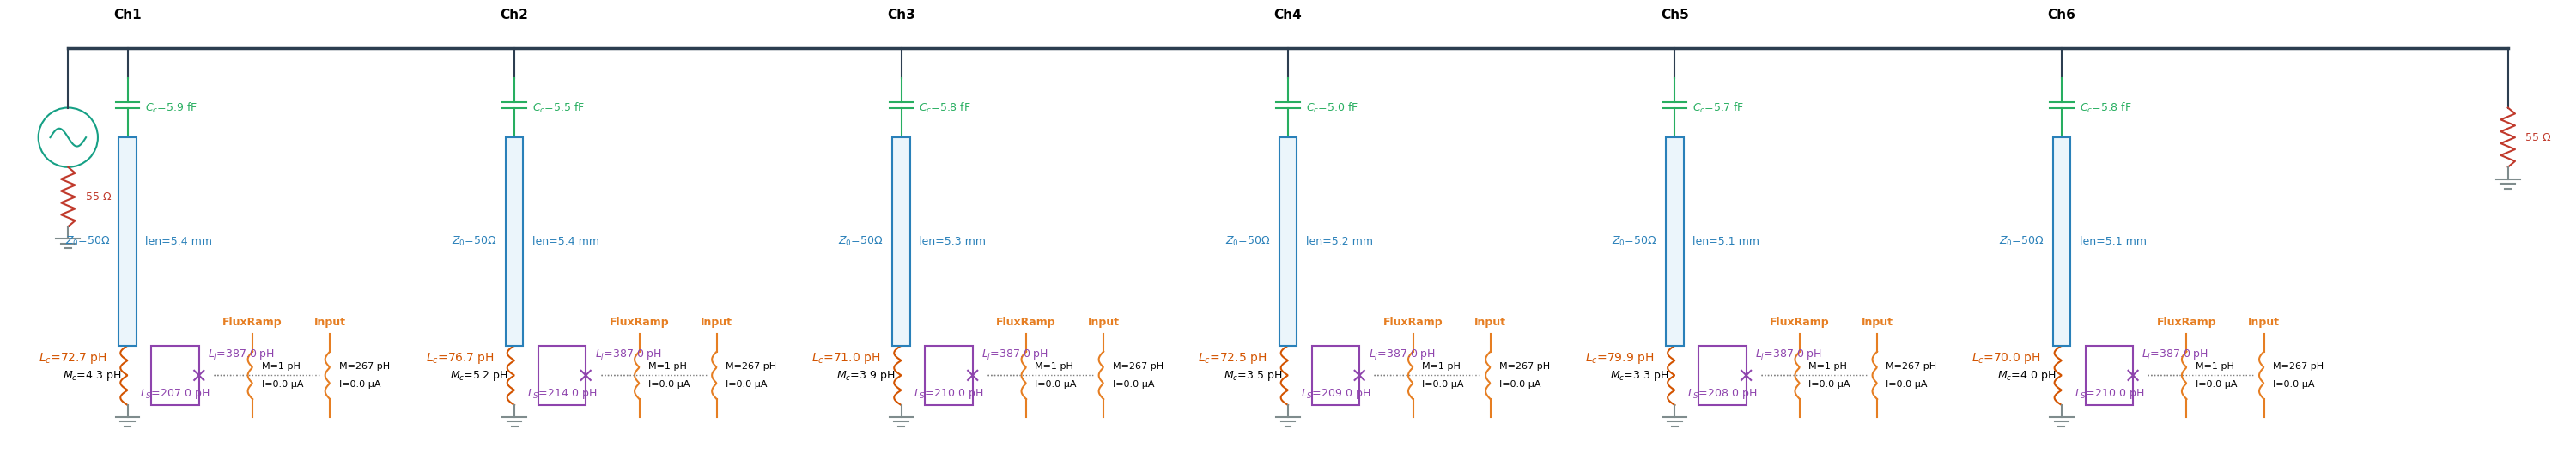

In [3]:
VNA = VNA_Simulator(z0=55, P_rf_dBm = -67)

squids = []
num_channels = 6
for i in range(num_channels):
    squid_ch = SQUID(L_j=L_j*1e-12, L_s=Lss[i]*1e-12, lamb=None, phi_ext=0.0) 
    squid_ch.add_flux_line("FluxRamp", M=Mfr*1e-12, initial_current=0.0)
    squid_ch.add_flux_line("Input", M=Min*1e-12)  
    
    ind_ch = Inductor(Lts[i]*1e-12)
    tuned_L_ch = ScreenedInductor(primary_inductor=ind_ch, screening_device=squid_ch, M=Mcs[i]*1e-12)
    squids.append(squid_ch)
    params = [0, 0, frs[i], Qls[i], Qcs[i]]
    length, Cc_val, Qi_val = extract_physical_params(params, tuned_L_ch, Cc_in=Ccs[i]*1e-15)
    cap_ch = Capacitor(C=Cc_val)
    phys_res = Resonator(length=length, load=tuned_L_ch, v_p=1.15e8, Qi=Qi_val, Qr=Qls[i], Qc=Qcs[i])
    channel = Channel(name=f"Ch{i+1}") 
    channel.add(cap_ch)
    channel.add(phys_res)
    VNA.add(channel, 'shunt')

VNA.draw_schematic(use_color=True, max_draw=6)

(20000, 2, 2)


/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


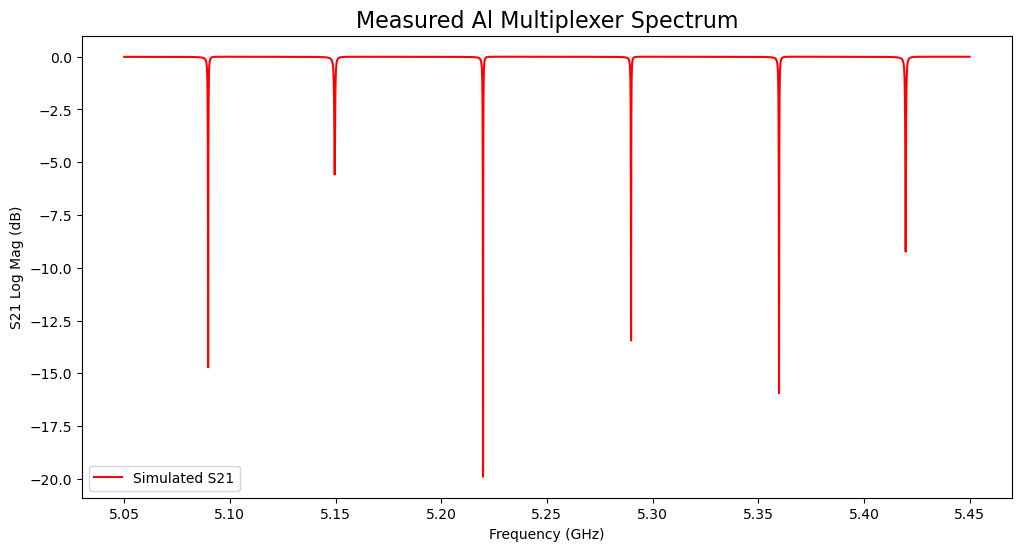

In [4]:
freqs = np.linspace(5.05e9, 5.45e9,20000)
for squid in squids:
    squid.flux_lines["FluxRamp"].set_flux(0)
S = VNA.get_s_matrix(freqs)

plt.figure(figsize=(12,6))
plt.plot(freqs*1e-9, 20*np.log10(S[1,0]), color = 'r', label = "Simulated S21")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.title("Measured Al Multiplexer Spectrum", fontsize = 16)

plt.legend()
# S_baseline = VNA.get_s_matrix(freqs)
# baseline_peaks_idx = find_all_peaks(freqs, S_baseline[1, 0])
# baseline_frs = freqs[baseline_peaks_idx]

# channels = [comp for comp, mode in VNA.chain if isinstance(comp, Channel)]

# for squid in squids:
#     squid.flux_lines["FluxRamp"].set_flux(0.7*Phi0)
    

# res_freq = channel.get_resonance(f_guess = baseline_frs)
# plt.axvline(res_freq*1e-9)
    
    
# S = VNA.get_s_matrix(freqs)

# plt.plot(freqs*1e-9, 20*np.log10(S[1,0]), color = 'b', label = "Simulated S21 (shifted)")

# plt.axvline(baseline_frs*1e-9)
# plt.xlim([5.09-0.001,5.09+0.001])
plt.show()



Using flux_array[50] = 0.00e+00 Wb as the zero-flux reference point.
--- Running simulation for P_rf = -66.8 dBm ---
(5000, 2, 2)
Tracking complete for -66.8 dBm.
--- Running simulation for P_rf = -73.8 dBm ---
(5000, 2, 2)
Tracking complete for -73.8 dBm.
--- Running simulation for P_rf = -78.8 dBm ---
(5000, 2, 2)
Tracking complete for -78.8 dBm.
--- Running simulation for P_rf = -103.8 dBm ---
(5000, 2, 2)
Tracking complete for -103.8 dBm.

--- Plotting Results ---


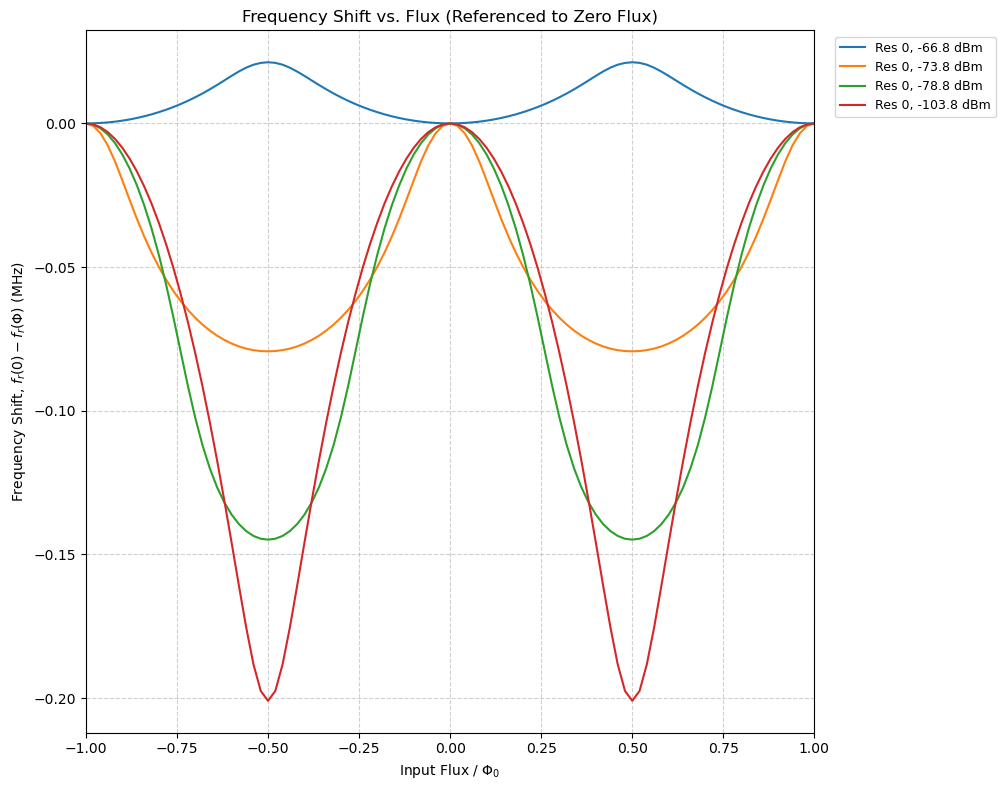

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Setup ---
powers_dBm = [-66.8, -73.8, -78.8, -103.8]
results_by_power = {}
flux_array = np.linspace(-1 * Phi0, 1 * Phi0, 101) 
freqs_sweep = np.linspace(5.05e9, 5.45e9, 5000)
zero_flux_idx = np.argmin(np.abs(flux_array))
print(f"Using flux_array[{zero_flux_idx}] = {flux_array[zero_flux_idx]:.2e} Wb as the zero-flux reference point.")
channels = [comp for comp, mode in VNA.chain if isinstance(comp, Channel)]

# --- Main Simulation Loop ---
for power_dBm in powers_dBm:
    print(f"--- Running simulation for P_rf = {power_dBm} dBm ---")
    VNA.P_rf = 10**(power_dBm / 10) / 1000
    S_baseline = VNA.get_s_matrix(freqs_sweep)
    baseline_peaks_idx = find_all_peaks(freqs_sweep, S_baseline[1, 0])
    guesses = freqs_sweep[baseline_peaks_idx]
    
    if len(guesses) != len(channels):
        print(f"Warning: Found {len(guesses)} peaks but there are {len(channels)} channels.")

    for squid in squids:
        if "FluxRamp" in squid.flux_lines:
            squid.set_current("FluxRamp", 0.0)

    all_frs_for_power = []
    for i, channel in enumerate(channels):
        if i >= len(guesses): 
            print(f"Skipping channel {i} due to missing frequency guess.")
            continue

        fr_vs_flux = []
        current_guess = guesses[i]
        for flux in flux_array:
            squids[i].flux_lines["FluxRamp"].set_flux(flux)
            fr = channel.get_resonance(current_guess)
            current_guess = fr
            fr_vs_flux.append(fr)
        
        all_frs_for_power.append(fr_vs_flux)
        
    results_by_power[power_dBm] = np.array(all_frs_for_power)
    print(f"Tracking complete for {power_dBm} dBm.")

# --- Plotting Results ---
print("\n--- Plotting Results ---")
plt.figure(figsize=(12, 8))
num_resonators_to_plot = min(1, len(channels))

for res_idx in range(num_resonators_to_plot):
    for power_idx, power_dBm in enumerate(powers_dBm):
        frs_for_power = results_by_power.get(power_dBm)
        
        if frs_for_power is not None and res_idx < len(frs_for_power):
            fr_data = frs_for_power[res_idx]
            
            fr_no_flux = fr_data[zero_flux_idx]

            y_data = 1e-6 * (fr_data - fr_no_flux)
            
            plt.plot(flux_array / Phi0, -y_data, 
                     label=f"Res {res_idx}, {power_dBm} dBm")

plt.xlim([np.min(flux_array) / Phi0, np.max(flux_array) / Phi0])
plt.xlabel("Input Flux / $\Phi_0$")
plt.ylabel("Frequency Shift, $f_r(0) - f_r(\Phi)$ (MHz)")
plt.title("Frequency Shift vs. Flux (Referenced to Zero Flux)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
